In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_cond

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=True)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=500,adc_last_gap=10)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.adc.set_sample_times(adc_sample_times=32)
chip.clk_manager.set_cyc(10, 10,delay3=10)
chip.add_compiler("../compiler/code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 59546
正在编译文件:  ../compiler/code/asm_ds(2).txt
正在编译文件:  ../compiler/code/汇编指令解释测试.txt
编译指令 jmp_r reg2 时出错: 'COMPILER' object has no attribute 'jmp_r'


In [3]:
chip.set_cim_reset(flag1=False,flag2=None,flag3=None,reset_ans=0)
chip.set_cim_reset(flag1=False,flag2=None,flag3="v1.4",reset_ans=0)
chip.set_cim_reset(flag1=False,flag2=None,flag3="v1.4",reset_ans=1)

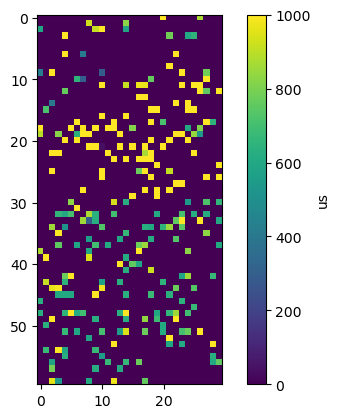

In [46]:

cross = np.ones((256,256))
# cross[pos]=1
v,c,r = chip.read4(crossbar=cross,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0,return_data=False,return_base=False)

plot_cond(c[:60,:30],vmax=1000)

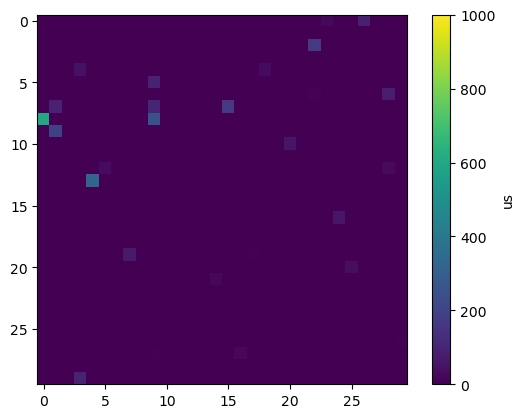

In [41]:
row = [i for i in range(30,60)]
col = [i for i in range(30)]
pos = np.ix_(row,col)
cross = np.zeros((256,256))
cross[pos]=1
v,c,r = chip.read4(crossbar=cross,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0,return_data=False,return_base=False)

plot_cond(c[pos],vmax=1000)

In [36]:
ans = np.zeros((40,30,30))

In [43]:
# 小于600us就不停的加tg写器件
write_times = 30
write_v = 5
start_v = 1
delta_v = 0.1
threshold = 600
for i in range(write_times):
    tg = start_v+i*delta_v
    _,cond,_ = chip.read4(crossbar=cross,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0,return_data=False,return_base=False)
    ans[i]=cond[pos]
    need_set = (cond<threshold)&cross.astype(bool)
    print(np.sum(need_set))
    chip.write4(crossbar=need_set,row_index=None,col_index=None,write_voltage=write_v,tg=tg,pulse_width=1e-3,set_device=True,split_type=0,row_type=0,col_type=0)

899
898
898
898
898
896
895
894
891
890
884
878
866
853
828
814
802
799
793
790
782
780
778
771
772
770
765
761
762
762


In [ ]:
row = [i for i in range(30,45)]
col = [i for i in range(30,45)]
pos = np.ix_(row,col)
cross = np.zeros((256,256))
cross[pos]=1



# 大于100us就不停的reset器件
write_times = 20
start_v = 1
delta_v = 0.1
threshold = 100
for i in range(write_times):
    v = start_v+i*delta_v
    _,cond,_ = chip.read4(crossbar=cross,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0,return_data=False,return_base=False)
    ans[i+20]=cond[pos]
    need_reset = (cond[pos]>threshold)&cross[pos].astype(bool)
    chip.write4(crossbar=need_reset,row_index=None,col_index=None,write_voltage=v,tg=5,pulse_width=1e-3,set_device=False,split_type=0,row_type=0,col_type=0)

IndexError: index 40 is out of bounds for axis 0 with size 40

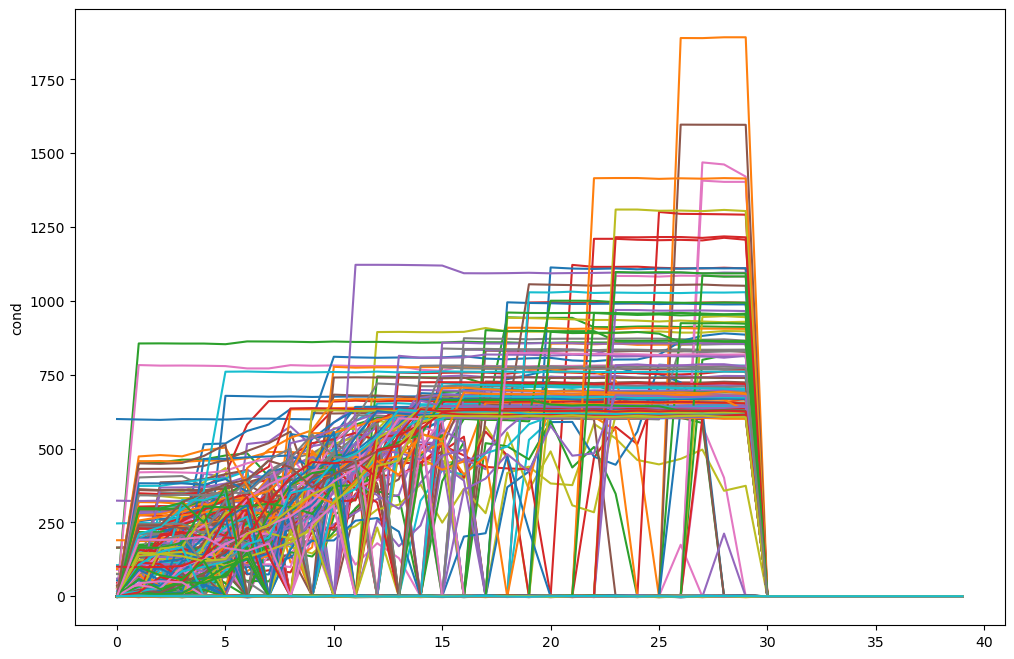

In [44]:
import numpy as np
import matplotlib.pyplot as plt

flattened_data = ans.reshape(60, -1)

plt.figure(figsize=(12, 8))
for i in range(30):
    for j in range(30):
        plt.plot(ans[:,i,j].flatten(), label=f'Point {i}')

# plt.title('Values of Each Point Across 40 Tests')
# plt.xlabel('Test Index')
plt.ylabel('cond')


plt.show()